# 04 - Federated Learning Setup

## Overview

Setup Flower framework, create non-IID client partitions using Dirichlet distribution, and prepare XGBoost/LightGBM NumPyClients.

**Output**: Client partitions, Flower server/client code

In [1]:
# Imports
import numpy as np
import pandas as pd
import os
import json
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/home/willtanoe/Documents/fl-xgb-thesis')
from src.config import (
    NUM_CLIENTS, DIRICHLET_ALPHA, SEED,
    XGB_PARAMS, LGB_PARAMS
)

# Paths
BASE = "/home/willtanoe/Documents/fl-xgb-thesis"
PREPROCESSED_DIR = f"{BASE}/results/preprocessed"
CLIENTS_DIR = f"{BASE}/results/clients"
FIGURES_DIR = f"{BASE}/results/figures"

os.makedirs(CLIENTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Num clients: {NUM_CLIENTS}")
print(f"Dirichlet alpha: {DIRICHLET_ALPHA}")
print(f"Clients dir: {CLIENTS_DIR}")

Num clients: 5
Dirichlet alpha: 1.0
Clients dir: /home/willtanoe/Documents/fl-xgb-thesis/results/clients


## 1. Load Preprocessed Data

In [2]:
print("Loading preprocessed data...")
train_df = pd.read_parquet(os.path.join(PREPROCESSED_DIR, "train.parquet"))

# Load metadata
with open(os.path.join(PREPROCESSED_DIR, "metadata.json"), 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
num_classes = metadata['num_classes']

print(f"Train shape: {train_df.shape}")
print(f"Features: {len(feature_cols)}")
print(f"Classes: {num_classes}")

Loading preprocessed data...
Train shape: (1372992, 44)
Features: 43
Classes: 34


## 2. Create Non-IID Client Partitions (Dirichlet)

In [3]:
def create_dirichlet_partitions(X, y, num_clients, alpha, seed=42):
    """
    Create non-IID client partitions using Dirichlet distribution.
    
    Args:
        X: Feature array
        y: Label array
        num_clients: Number of clients
        alpha: Dirichlet concentration parameter (lower = more non-IID)
        seed: Random seed
    
    Returns:
        dict: client_id -> (X_client, y_client)
    """
    np.random.seed(seed)
    
    classes = np.unique(y)
    num_classes = len(classes)
    
    # Generate Dirichlet distribution for each class
    # Dirichlet(alpha) gives proportions that sum to 1
    class_proportions = np.random.dirichlet(
        [alpha] * num_clients,  # concentration for each client
        num_classes             # one distribution per class
    )
    
    # Assign samples to clients based on class proportions
    client_data = {i: {'X': [], 'y': []} for i in range(num_clients)}
    
    for cls_idx, cls in enumerate(classes):
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)
        
        # Split this class's samples across clients
        splits = np.split(cls_indices, 
                         np.cumsum(class_proportions[cls_idx] * len(cls_indices))[:-1].astype(int))
        
        for client_id, split in enumerate(splits):
            client_data[client_id]['X'].append(X[split])
            client_data[client_id]['y'].append(y[split])
    
    # Concatenate for each client
    result = {}
    for client_id in range(num_clients):
        X_client = np.vstack(client_data[client_id]['X'])
        y_client = np.concatenate(client_data[client_id]['y'])
        result[client_id] = (X_client, y_client)
    
    return result

print("Creating Dirichlet partitions...")
X_train = train_df[feature_cols].values
y_train = train_df['label'].values

client_partitions = create_dirichlet_partitions(
    X_train, y_train, 
    num_clients=NUM_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    seed=SEED
)

# Show partition sizes
print("\nClient partition sizes:")
for cid, (X_c, y_c) in client_partitions.items():
    print(f"  Client {cid}: {X_c.shape[0]:,} samples, {len(np.unique(y_c))} classes")

Creating Dirichlet partitions...

Client partition sizes:
  Client 0: 259,422 samples, 33 classes
  Client 1: 174,669 samples, 34 classes
  Client 2: 260,740 samples, 34 classes
  Client 3: 343,538 samples, 34 classes
  Client 4: 334,623 samples, 34 classes


## 3. Visualize Non-IID Distribution

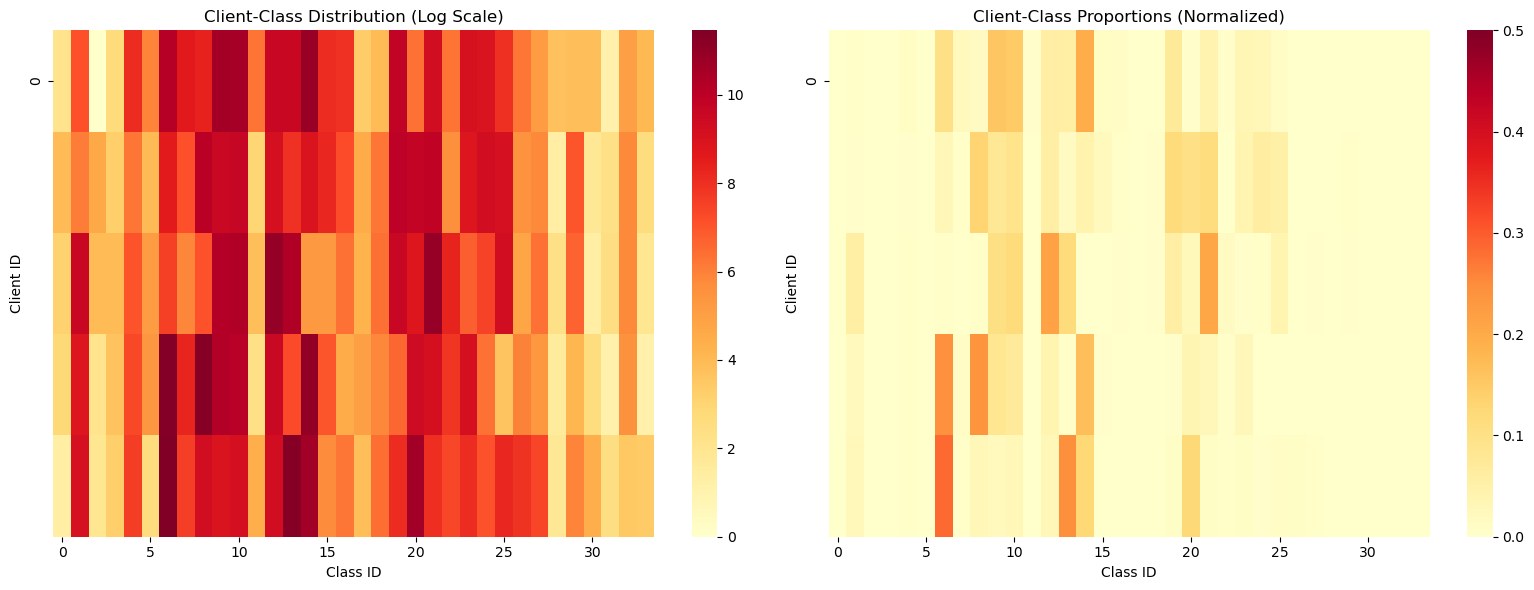

Figure saved: /home/willtanoe/Documents/fl-xgb-thesis/results/figures/03_non_iid_distribution.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create heatmap of class distribution per client
distribution = np.zeros((NUM_CLIENTS, num_classes))
for cid, (X_c, y_c) in client_partitions.items():
    unique, counts = np.unique(y_c, return_counts=True)
    for cls, cnt in zip(unique, counts):
        distribution[cid, cls] = cnt

# Normalize per client
distribution_norm = distribution / distribution.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts (log scale)
ax1 = axes[0]
sns.heatmap(np.log1p(distribution), ax=ax1, cmap='YlOrRd', 
            xticklabels=5, yticklabels=5)
ax1.set_title('Client-Class Distribution (Log Scale)')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Client ID')

# Normalized (proportions)
ax2 = axes[1]
sns.heatmap(distribution_norm, ax=ax2, cmap='YlOrRd',
            xticklabels=5, yticklabels=5, vmin=0, vmax=0.5)
ax2.set_title('Client-Class Proportions (Normalized)')
ax2.set_xlabel('Class ID')
ax2.set_ylabel('Client ID')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_non_iid_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: {FIGURES_DIR}/03_non_iid_distribution.png")

## 4. Save Client Partitions

In [5]:
print("\nSaving client partitions...")

for cid, (X_c, y_c) in client_partitions.items():
    client_dir = os.path.join(CLIENTS_DIR, f"client_{cid}")
    os.makedirs(client_dir, exist_ok=True)
    
    # Save as parquet
    df = pd.DataFrame(X_c, columns=feature_cols)
    df['label'] = y_c
    df.to_parquet(os.path.join(client_dir, "data.parquet"), index=False)
    
    # Save metadata
    client_meta = {
        'client_id': cid,
        'num_samples': int(len(y_c)),
        'num_classes': len(np.unique(y_c)),
        'classes': sorted(np.unique(y_c).tolist())
    }
    with open(os.path.join(client_dir, "metadata.json"), 'w') as f:
        json.dump(client_meta, f, indent=2)
    
    print(f"  Client {cid}: {X_c.shape[0]:,} samples saved")

print(f"\nAll client partitions saved to: {CLIENTS_DIR}")


Saving client partitions...
  Client 0: 259,422 samples saved
  Client 1: 174,669 samples saved
  Client 2: 260,740 samples saved
  Client 3: 343,538 samples saved
  Client 4: 334,623 samples saved

All client partitions saved to: /home/willtanoe/Documents/fl-xgb-thesis/results/clients


## 5. Create Flower Client Classes

In [6]:
import flwr as fl
import xgboost as xgb
import lightgbm as lgb

class XGBClient(fl.client.NumPyClient):
    """Flower NumPyClient for XGBoost."""
    
    def __init__(self, cid, X_train, y_train, X_val, y_val, params):
        self.cid = cid
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.params = params.copy()
        self.model = None
    
    def fit(self, parameters, config):
        """Train locally."""
        # Update params from config
        if self.model is None:
            self.params['num_class'] = len(np.unique(self.y_train))
            self.model = xgb.XGBClassifier(**self.params)
        
        # Fit
        self.model.fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False
        )
        
        # Return updated parameters
        return self.model.get_params(), len(self.X_train), {}
    
    def evaluate(self, parameters, config):
        """Evaluate locally."""
        from sklearn.metrics import f1_score, accuracy_score
        
        if self.model is None:
            return 0.0, len(self.X_val), {'f1_macro': 0.0}
        
        y_pred = self.model.predict(self.X_val)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        acc = accuracy_score(self.y_val, y_pred)
        
        return float(acc), len(self.X_val), {'f1_macro': float(f1)}


class LGBClient(fl.client.NumPyClient):
    """Flower NumPyClient for LightGBM."""
    
    def __init__(self, cid, X_train, y_train, X_val, y_val, params):
        self.cid = cid
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.params = params.copy()
        self.model = None
    
    def fit(self, parameters, config):
        """Train locally."""
        if self.model is None:
            self.params['num_class'] = len(np.unique(self.y_train))
            self.model = lgb.LGBMClassifier(**self.params)
        
        self.model.fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
        )
        
        return self.model.get_params(), len(self.X_train), {}
    
    def evaluate(self, parameters, config):
        """Evaluate locally."""
        from sklearn.metrics import f1_score, accuracy_score
        
        if self.model is None:
            return 0.0, len(self.X_val), {'f1_macro': 0.0}
        
        y_pred = self.model.predict(self.X_val)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        acc = accuracy_score(self.y_val, y_pred)
        
        return float(acc), len(self.X_val), {'f1_macro': float(f1)}

print("Flower clients defined: XGBClient, LGBClient")

Flower clients defined: XGBClient, LGBClient


## 6. Save Client Factory Functions

In [7]:
# Save client factory for training notebook
client_factory_code = '''
"""Client factory for Flower FL training."""

import os
import numpy as np
import pandas as pd
import flwr as fl
import xgboost as xgb
import lightgbm as lgb
import joblib
from sklearn.metrics import f1_score, accuracy_score

CLIENTS_DIR = "/home/willtanoe/Documents/fl-xgb-thesis/results/clients"
PREPROCESSED_DIR = "/home/willtanoe/Documents/fl-xgb-thesis/results/preprocessed"

# Load metadata
with open(os.path.join(PREPROCESSED_DIR, "metadata.json"), 'r') as f:
    metadata = json.load(f)
feature_cols = metadata['feature_cols']

# Load validation data for client evaluation
val_df = pd.read_parquet(os.path.join(PREPROCESSED_DIR, "val.parquet"))
X_val = val_df[feature_cols].values
y_val = val_df['label'].values

def load_client_data(cid):
    """Load data for a specific client."""
    client_dir = os.path.join(CLIENTS_DIR, f"client_{cid}")
    df = pd.read_parquet(os.path.join(client_dir, "data.parquet"))
    X = df[feature_cols].values
    y = df['label'].values
    return X, y

class XGBClient(fl.client.NumPyClient):
    def __init__(self, cid, params):
        self.cid = cid
        self.X_train, self.y_train = load_client_data(cid)
        self.X_val, self.y_val = X_val, y_val
        self.params = params.copy()
        self.model = None
    
    def fit(self, parameters, config):
        if self.model is None:
            self.params['num_class'] = len(np.unique(self.y_train))
            self.model = xgb.XGBClassifier(**self.params)
        
        self.model.fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False
        )
        return self.model.get_params(), len(self.X_train), {}
    
    def evaluate(self, parameters, config):
        if self.model is None:
            return 0.0, len(self.X_val), {'f1_macro': 0.0}
        y_pred = self.model.predict(self.X_val)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        acc = accuracy_score(self.y_val, y_pred)
        return float(acc), len(self.X_val), {'f1_macro': float(f1)}

class LGBClient(fl.client.NumPyClient):
    def __init__(self, cid, params):
        self.cid = cid
        self.X_train, self.y_train = load_client_data(cid)
        self.X_val, self.y_val = X_val, y_val
        self.params = params.copy()
        self.model = None
    
    def fit(self, parameters, config):
        if self.model is None:
            self.params['num_class'] = len(np.unique(self.y_train))
            self.model = lgb.LGBMClassifier(**self.params)
        
        self.model.fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
        )
        return self.model.get_params(), len(self.X_train), {}
    
    def evaluate(self, parameters, config):
        if self.model is None:
            return 0.0, len(self.X_val), {'f1_macro': 0.0}
        y_pred = self.model.predict(self.X_val)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        acc = accuracy_score(self.y_val, y_pred)
        return float(acc), len(self.X_val), {'f1_macro': float(f1)}

def get_client_fn(model_type='xgb', params=None):
    """Return a client_fn for Flower."""
    def client_fn(cid):
        cid = int(cid)
        if model_type == 'xgb':
            return XGBClient(cid, params or {})
        else:
            return LGBClient(cid, params or {})
    return client_fn
'''

with open(os.path.join(CLIENTS_DIR, 'client_factory.py'), 'w') as f:
    f.write(client_factory_code)

print(f"Client factory saved: {CLIENTS_DIR}/client_factory.py")

Client factory saved: /home/willtanoe/Documents/fl-xgb-thesis/results/clients/client_factory.py


## 7. Summary

In [9]:
# Save FL setup config
fl_config = {
    'num_clients': NUM_CLIENTS,
    'dirichlet_alpha': DIRICHLET_ALPHA,
    'seed': SEED,
    'clients_dir': CLIENTS_DIR,
    'xgb_params': {k: v for k, v in XGB_PARAMS.items() if not isinstance(v, dict)},
    'lgb_params': {k: v for k, v in LGB_PARAMS.items() if not isinstance(v, dict)}
}

with open(os.path.join(CLIENTS_DIR, 'fl_config.json'), 'w') as f:
    json.dump(fl_config, f, indent=2)

print("FL setup complete!")
print(f"\nSummary:")
print(f"  Clients: {NUM_CLIENTS}")
print(f"  Non-IID alpha: {DIRICHLET_ALPHA}")
print(f"  Clients dir: {CLIENTS_DIR}")
print(f"  Client factory: {CLIENTS_DIR}/client_factory.py")

FL setup complete!

Summary:
  Clients: 5
  Non-IID alpha: 1.0
  Clients dir: /home/willtanoe/Documents/fl-xgb-thesis/results/clients
  Client factory: /home/willtanoe/Documents/fl-xgb-thesis/results/clients/client_factory.py
